In [25]:
import matplotlib.pyplot as plt
import numpy as np
import random
from itertools import permutations

def simulate(attention_sequence, thresh_prob, att_prob, total_duration = 10, signal_duration = 3):
    no_attention_modes = 2
    signal_start = random.randint(0, total_duration - signal_duration)
    signal_states = [elt for elt in range(signal_start, signal_start+signal_duration)]
    obs_certainity_possible = (att_prob-0.5)/(no_attention_modes-1) * np.arange(no_attention_modes) + 0.5 
    prior_list = (total_duration-signal_duration+1) * [1/(total_duration-signal_duration+1)] + (signal_duration-1) * [0]
    
    def compute_joint(candidate_signal_start, obs_list):
        candidate_signal_states = [elt for elt in range(candidate_signal_start, candidate_signal_start+signal_duration)]
        joint = prior_list[candidate_signal_start]
        for time_ind in range(len(obs_list)):
            if time_ind in candidate_signal_states:
                if obs_list[time_ind] == 0:
                    joint *= (1 - obs_certainity_possible[attention_sequence[time_ind]])
                elif obs_list[time_ind] == 1:
                    joint *= obs_certainity_possible[attention_sequence[time_ind]]
                else:
                    print('Obs has to be 0 or 1.')
            elif time_ind not in candidate_signal_states:
                if obs_list[time_ind] == 0:
                    joint *= obs_certainity_possible[attention_sequence[time_ind]]
                elif obs_list[time_ind] == 1:
                    joint *= (1 - obs_certainity_possible[attention_sequence[time_ind]])
                else:
                    print('Obs has to be 0 or 1.') 
        return joint
    
    def find_start_time_posterior(candidate_signal_start, obs_list):
        numerator = compute_joint(candidate_signal_start, obs_list)
        denominator = 0
        for candidate_signal_start_prime in range(total_duration-signal_duration+1):
            denominator += compute_joint(candidate_signal_start_prime, obs_list)
        return numerator/denominator
    
    def find_belief(obs_list):
        belief = 0
        for ind in range(max(0, len(obs_list)-signal_duration), len(obs_list)):
            belief += find_start_time_posterior(ind, obs_list)
        return belief  
    
    belief_list = []
    obs_list = []
    rw_list = []
    lick_list = []
    done = False
    reward = 0

    
    for time in range(total_duration):
        if done:
            break
        if time in signal_states:
            obs = np.random.binomial(size=1, n=1, p= obs_certainity_possible[attention_sequence[time]])[0]
        else:
            obs = 1 - np.random.binomial(size=1, n=1, p= obs_certainity_possible[attention_sequence[time]])[0]
        obs_list.append(obs)
        belief = find_belief(obs_list)
        belief_list.append(belief)
        if belief > thresh_prob:
            lick_list.append(1)
            done = True 
            if time in signal_states:
                reward = 1
            rw_list.append(reward)
        else:
            lick_list.append(0)
    return reward

def generate_attention_lists(no_high_attentions, total_duration, signal_duration):
    initial_list = [1] * no_high_attentions + [0] * (total_duration - 2 * (signal_duration-1) - no_high_attentions)
    attention_permutations = set(permutations(initial_list))
    result_lists = [(signal_duration-1) * [0] + list(permutation) + (signal_duration-1) * [0] for permutation in attention_permutations]
    return result_lists


# att_prob_list =[.6, .7, .8, .9]
att_prob_list =[.6]
# thresh_prob_list = [.4, .5, .6, .7, .8, .9]
# thresh_prob_list = [.1, .2, .3, .4, .5, .6]
thresh_prob_list = [.1, .2, .3]

# att_prob_list =[.6]
# thresh_prob_list = [.4]

# att_prob = .7
# thresh_prob = .4

signal_duration = 4
# signal_duration = 2

# total_duration = 20
# no_high_attentions = 10
total_duration = 12
no_high_attentions = 5

# runs_per_attention_seq = 100
runs_per_attention_seq = 1000
# runs_per_attention_seq = 10

attention_sequences_list = generate_attention_lists(no_high_attentions, total_duration, signal_duration)
dict = {} # {att_prob:{thresh_prob}}
dict['attention_sequences_list'] = attention_sequences_list
for att_prob in att_prob_list:
    dict[att_prob] = {}
    for thresh_prob in thresh_prob_list:
        avg_reward_list = []
        for attention_sequence in attention_sequences_list:
            tot_reward = 0
            for _ in range(runs_per_attention_seq):
                tot_reward += simulate(attention_sequence, thresh_prob, att_prob, total_duration, signal_duration)
            avg_reward_list.append(tot_reward/runs_per_attention_seq)
        dict[att_prob][thresh_prob] = avg_reward_list

# for ind in np.where(np.array(avg_reward_list) == max(avg_reward_list))[0]:
#     print(attention_sequences_list[ind])
# print(f'maximum reward is {max(avg_reward_list)}')

In [23]:
from auditoryforage.utils import save_pickle_file
file_name = './simulation_results.pkl'
save_pickle_file(dict, file_name)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_fourier_transform(binary_sequence, sampling_rate):
#     # Calculate the Fourier Transform
#     fft_result = np.fft.fft(binary_sequence)
    
#     # Calculate the frequencies corresponding to the Fourier Transform result
#     freqs = np.fft.fftfreq(len(binary_sequence), d=1/sampling_rate)
    
#     # Plot the magnitude spectrum
#     plt.figure(figsize=(10, 6))
#     plt.plot(freqs, np.abs(fft_result))
#     plt.title('Fourier Transform - Magnitude Spectrum')
#     plt.xlabel('Frequency (Hz)')
#     plt.ylabel('Magnitude')
#     plt.grid(True)
#     plt.show()

# # Example binary sequence
# binary_sequence = np.array([0, 1, 0, 1, 0, 1, 0, 1])

# # Set the sampling rate (how often the data is sampled)
# sampling_rate = 1  # Assuming data is sampled every second

# # Plot the Fourier Transform
# plot_fourier_transform(binary_sequence, sampling_rate)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_fourier_transform(binary_sequence, sampling_rate):
#     # Calculate the Fourier Transform
#     fft_result = np.fft.fft(binary_sequence)
    
#     # Calculate the frequencies corresponding to the Fourier Transform result
#     freqs = np.fft.fftfreq(len(binary_sequence), d=1/sampling_rate)
    
#     # Plot the magnitude spectrum
#     plt.figure(figsize=(10, 6))
#     plt.stem(freqs, np.abs(fft_result), use_line_collection=True)  # Use stem plot for better clarity
#     plt.title('Fourier Transform - Magnitude Spectrum')
#     plt.xlabel('Frequency (Hz)')
#     plt.ylabel('Magnitude')
#     plt.grid(True)
#     plt.show()

# # Example binary sequence (longer sequence)
# binary_sequence = np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# # Set the sampling rate (how often the data is sampled)
# sampling_rate = 1  # Assuming data is sampled every second

# # Plot the Fourier Transform
# plot_fourier_transform(binary_sequence, sampling_rate)


In [ ]:
# for ind in np.argsort(avg_reward_list)[-10:]:
#     plt.figure()
#     plt.plot(attention_sequences_list[ind])

In [ ]:
# for ind in np.argsort(avg_reward_list)[:10]:
#     plt.figure()
#     plt.plot(attention_sequences_list[ind])

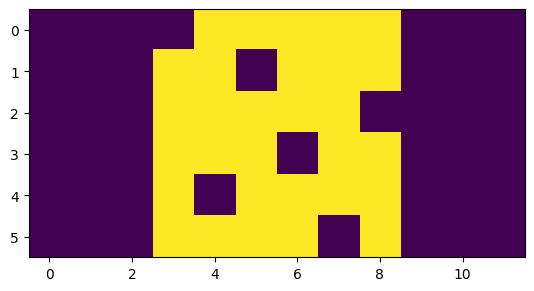

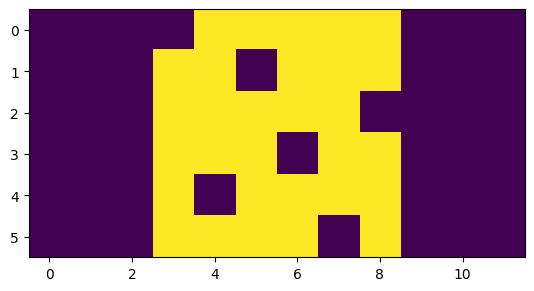

In [28]:
sorted_attention_sequences_list = [attention_sequences_list[ind] for ind in list(np.argsort(avg_reward_list))]

plt.figure()
plt.imshow(sorted_attention_sequences_list[:10])
plt.show()

plt.figure()
plt.imshow(sorted_attention_sequences_list[-10:])
plt.show()

In [35]:
len(sorted_attention_sequences_list[:10])

6

In [ ]:
certainity_list = list(dict.keys())[1:]
thresh_list = list(dict[0.6].keys())

In [ ]:
for certainity in certainity_list:
    plt.plot([np.max(dict[certainity][thresh]) for thresh in thresh_list])
plt.show()
    

In [ ]:
thresh_list

In [ ]:
certainity_list

In [ ]:

plt.plot([np.max(dict[certainity][thresh]) for thresh in thresh_list])